In [1]:
import sys
sys.path.append('../src')

import torch

from model import UNet
from utils import *
from datamodule import Normalizer

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [3]:
experiment_dir = '../mlruns/790155756705826000/aaf9a37d4dfb4a04be7c4a1c945594cc'
# Load configuration

import os

def load_config(experiment_dir):
    config_dir = os.path.join(experiment_dir, 'params')
    config = {}
    for param_file in os.listdir(config_dir):
        with open(os.path.join(config_dir, param_file), 'r') as f:
            value = f.read().strip()
            key = param_file    # no extension
            # Try to convert to int or float if possible
            try:
                value = int(value)
            except ValueError:
                try:
                    value = float(value)
                except ValueError:
                    pass
            config[key] = value
            
    return config

config = load_config(experiment_dir)
config

{'out_channels': 4,
 'depth': 5,
 'learning_rate': 0.00015,
 'kernel_size': 3,
 'base_filters': 32,
 'padding': 1,
 'in_channels': 1}

In [4]:
# Load model weights
model_dir = os.path.join(experiment_dir, 'checkpoints')
checkpoint_file = os.listdir(model_dir)[-1]  # Get the latest checkpoint
model = UNet.load_from_checkpoint(os.path.join(model_dir, checkpoint_file))

In [5]:
model.to(device)
model.eval()

UNet(
  (encoders): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      

In [6]:
# Load sample data
import numpy as np

data = np.load('../data/mixer_128.npz')
inputs, outputs = data['inputs'], data['outputs']
print(f'Inputs shape: {inputs.shape}, Outputs shape: {outputs.shape}')

Inputs shape: (871, 1, 128, 128), Outputs shape: (871, 4, 128, 128)


In [7]:
# Load normalizer
normalizer_path = os.path.join(experiment_dir, 'artifacts/normalizer.npz')
normalizer = Normalizer.load(normalizer_path)
normalizer

In [14]:
example_input = inputs[0:1]  # Take the first sample
example_output = outputs[0:1]
output = model(torch.tensor(example_input, dtype=torch.float32).to(device))
output = normalizer.inverse_transform(output.cpu().detach())
output[0, :3, :, :]

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='mps:0')


tensor([[[ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02],
         [ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02],
         [ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02],
         ...,
         [ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02],
         [ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02],
         [ 2.4993e-02,  2.4993e-02,  2.4993e-02,  ...,  2.4993e-02,
           2.4993e-02,  2.4993e-02]],

        [[-2.9028e-05, -2.9028e-05, -2.9028e-05,  ..., -2.9028e-05,
          -2.9028e-05, -2.9028e-05],
         [-2.9028e-05, -2.9028e-05, -2.9028e-05,  ..., -2.9028e-05,
          -2.9028e-05, -2.9028e-05],
         [-2.9028e-05, -2.9028e-05, -2.9028e-05,  ..., -2.9028e-05,
          -2.9028e-05, -2.9028e-05],
         ...,
         [-2.9028e-05, -2

In [9]:
coords_array = load_coordinates('../data/coordinates_128.csv')
coords_array

array([[5.000e-04, 5.000e-04, 1.000e-03, 2.000e-09],
       [1.500e-03, 5.000e-04, 1.000e-03, 2.000e-09],
       [2.500e-03, 5.000e-04, 1.000e-03, 2.000e-09],
       ...,
       [1.255e-01, 1.275e-01, 1.000e-03, 2.000e-09],
       [1.265e-01, 1.275e-01, 1.000e-03, 2.000e-09],
       [1.275e-01, 1.275e-01, 1.000e-03, 2.000e-09]], shape=(16384, 4))

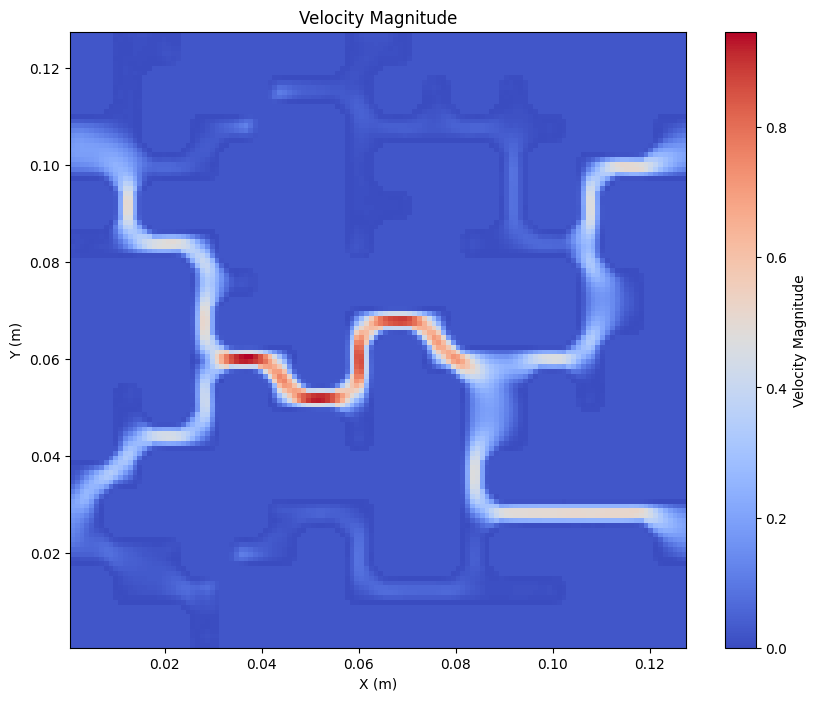

In [10]:
plot_velocity_magnitude(output[0], coords_array)